# Load and run models

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
cd ../..

/home/resingh/geoarches


In [4]:
from geoarches.lightning_modules import load_module

/home/resingh/miniconda3/envs/geoarches/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load ArchesWeather

In [5]:
# load_module will look in modelstore/
model, config = load_module("archesweather-m-seed0")

/home/resingh/miniconda3/envs/geoarches/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


##### NORM SCHEME:  pangu  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Loss coefficients computed with normalization scheme:            pangu, pow: 2, delta normalization: True,            use_weatherbench_lat_coeffs: True
Restored from modelstore/archesweather-m-seed0/checkpoints/checkpoint.ckpt


In [6]:
# we can also load the 4-members deterministic ensemble ArchesWeather-Mx4 like so:

model, config = load_module(
    "archesweather-m-seed0",
    avg_with_modules=[
        "archesweather-m-seed1",
        "archesweather-m-skip-seed0",
        "archesweather-m-skip-seed1",
    ],
)

##### NORM SCHEME:  pangu  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Loss coefficients computed with normalization scheme:            pangu, pow: 2, delta normalization: True,            use_weatherbench_lat_coeffs: True
##### NORM SCHEME:  pangu  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Loss coefficients computed with normalization scheme:            pangu

## Era5 Dataloader

In [7]:
# load sample from dataloader
from geoarches.dataloaders.era5 import Era5Forecast

ds = Era5Forecast(
    stats_cfg=config.stats,
    path="data/era5_240/full",  # default path
    load_prev=True,  # whether to load previous state
    domain="test",  # domain to consider. domain = 'test' loads the 2020 period
)

12it [00:00, 42.00it/s]


start time 2019-12-31T00:00:00
##### NORM SCHEME:  pangu  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####


In [8]:
# The dataset returns a dict of TensorDict:
print("keys in a sample:", ds[0].keys())
# a state contains level and surface variables in a TensorDict, which is a specialized structure for dict of tensors
print("sample state", ds[0]["state"])

keys in a sample: dict_keys(['timestamp', 'hour_of_day', 'day_of_month', 'day_of_year', 'month', 'state', 'lead_time_hours', 'next_state', 'prev_state'])
sample state TensorDict(
    fields={
        level: Tensor(shape=torch.Size([6, 13, 121, 240]), device=cpu, dtype=torch.float32, is_shared=False),
        surface: Tensor(shape=torch.Size([4, 1, 121, 240]), device=cpu, dtype=torch.float32, is_shared=False)},
    batch_size=torch.Size([]),
    device=None,
    is_shared=False)


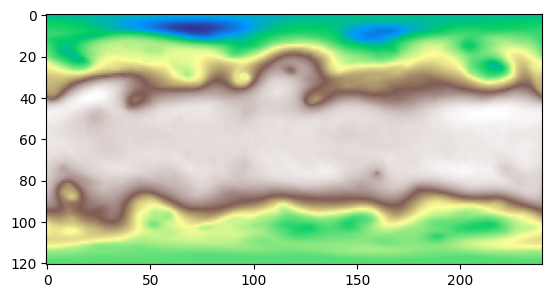

In [9]:
# we can visualize a sample, e.g. Z500, with the following

import matplotlib.pyplot as plt

plt.imshow(ds[0]["state"]["level"][0, 7], cmap="terrain")

## Run ArchesWeather

In [10]:
# now we can run inference with the deterministic model ArchesWeather:
import torch

torch.set_grad_enabled(False)

device = "cuda:0"

model = model.to(device)

batch = {k: v[None].to(device) for k, v in ds[0].items()}

pred = model(batch).cpu()

In [11]:
# optionally, we can denormalize the prediction to go back to real physical values
pred = ds.denormalize(pred)

24h Z500 prediction


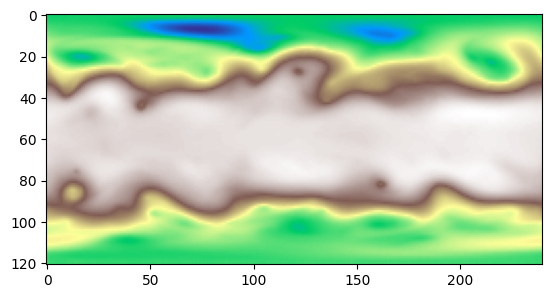

24h ground truth


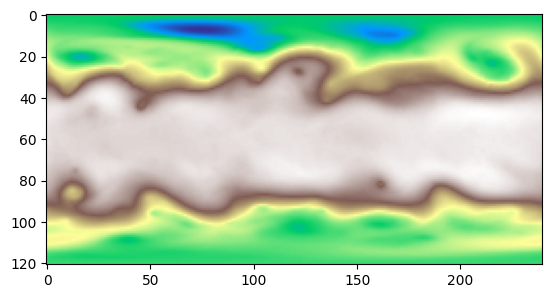

In [12]:
# we can visualize predictions, compared to ground truth

print("24h Z500 prediction")
plt.imshow(pred["level"][0, 0, 7], cmap="terrain")
plt.show()

print("24h ground truth")
plt.imshow(ds[0]["next_state"]["level"][0, 7], cmap="terrain")
plt.show()

In [13]:
# we can also do multistep rollouts with the deterministic model:
pred_multistep = model.forward_multistep(batch, iters=10)  # this does a 10-day rollout
# the rollout dimension is the second dimension in the predicted tensors
pred_multistep

TensorDict(
    fields={
        level: Tensor(shape=torch.Size([1, 10, 6, 13, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True),
        surface: Tensor(shape=torch.Size([1, 10, 4, 1, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True)},
    batch_size=torch.Size([1, 10]),
    device=cuda:0,
    is_shared=True)

## Loading and running ArchesWeatherGen

In [14]:
# loading ArchesWeatherFlow
device = "cuda:0"

# load_module will look in modelstore/
gen_model, gen_config = load_module("archesweathergen")

gen_model = gen_model.to(device)

##### NORM SCHEME:  pangu  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
##### NORM SCHEME:  pangu  #####
##### VARIABLES:  {'surface': ['10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'mean_sea_level_pressure'], 'level': ['geopotential', 'u_component_of_wind', 'v_component_of_wind', 'temperature', 'specific_humidity', 'vertical_velocity']}  #####
##### LEVELS:  [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]  #####
Loss coefficients computed with normalization scheme:            pangu, pow: 2, delta normalization: True,            use_weatherbench_lat_coeffs: True
Restored from modelstore/archesweather-m-seed0/checkpoints/checkpoint.

In [15]:
# run model on a sample
seed = 0
num_steps = 25  # if not provided to model.sample, model will use the default value (25)
scale_input_noise = 1.05

batch = {k: v[None].to(device) for k, v in ds[0].items()}


sample = gen_model.sample(
    batch, seed=seed, num_steps=num_steps, scale_input_noise=scale_input_noise
).cpu()

100%|██████████| 25/25 [00:08<00:00,  2.82it/s]


24h Z500 prediction


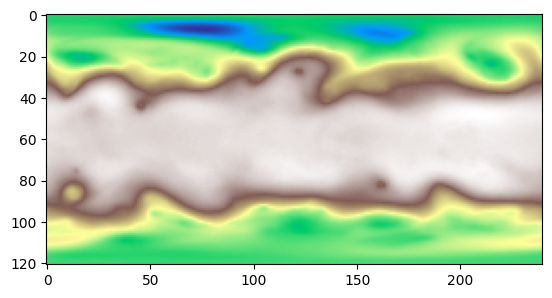

In [16]:
print("24h Z500 prediction")
plt.imshow(sample["level"][0, 0, 7], cmap="terrain")
plt.show()

In [17]:
# run a model auto-regressively

rollout_iterations = 10
n_members = 10

sample_multistep = [
    gen_model.sample_rollout(
        batch,
        batch_nb=0,  # should be different for each input
        member=i,
        iterations=rollout_iterations,
    )
    for i in range(n_members)
]

100%|██████████| 10/10 [01:57<00:00, 11.78s/it]


In [18]:
sample_multistep

[TensorDict(
     fields={
         level: Tensor(shape=torch.Size([1, 10, 6, 13, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True),
         surface: Tensor(shape=torch.Size([1, 10, 4, 1, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True)},
     batch_size=torch.Size([1, 10]),
     device=cuda:0,
     is_shared=True),
 TensorDict(
     fields={
         level: Tensor(shape=torch.Size([1, 10, 6, 13, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True),
         surface: Tensor(shape=torch.Size([1, 10, 4, 1, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True)},
     batch_size=torch.Size([1, 10]),
     device=cuda:0,
     is_shared=True),
 TensorDict(
     fields={
         level: Tensor(shape=torch.Size([1, 10, 6, 13, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True),
         surface: Tensor(shape=torch.Size([1, 10, 4, 1, 121, 240]), device=cuda:0, dtype=torch.float32, is_shared=True)},
     batch_size=torch.Size([1, 10])

In [26]:
from ipywidgets import IntSlider, interact

print("24h Z500 prediction")

member = 0
sample_multistep_member = sample_multistep[member].cpu()


def plot_frame(frame_index):
    plt.imshow(sample_multistep_member["level"][0, frame_index - 1, 0, 7], cmap="terrain")
    plt.title(f"Member {member}, Frame {frame_index}")
    plt.show()


interact(
    plot_frame,
    frame_index=IntSlider(
        min=1,
        max=sample_multistep_member.shape[1],
        step=1,
        value=0,
        description="Prediction Timedelta:",
    ),
)

24h Z500 prediction


interactive(children=(IntSlider(value=1, description='Prediction Timedelta:', max=10, min=1), Output()), _dom_…

<function __main__.plot_frame(frame_index)>